#### AULA 3
##### Subplot e layouts


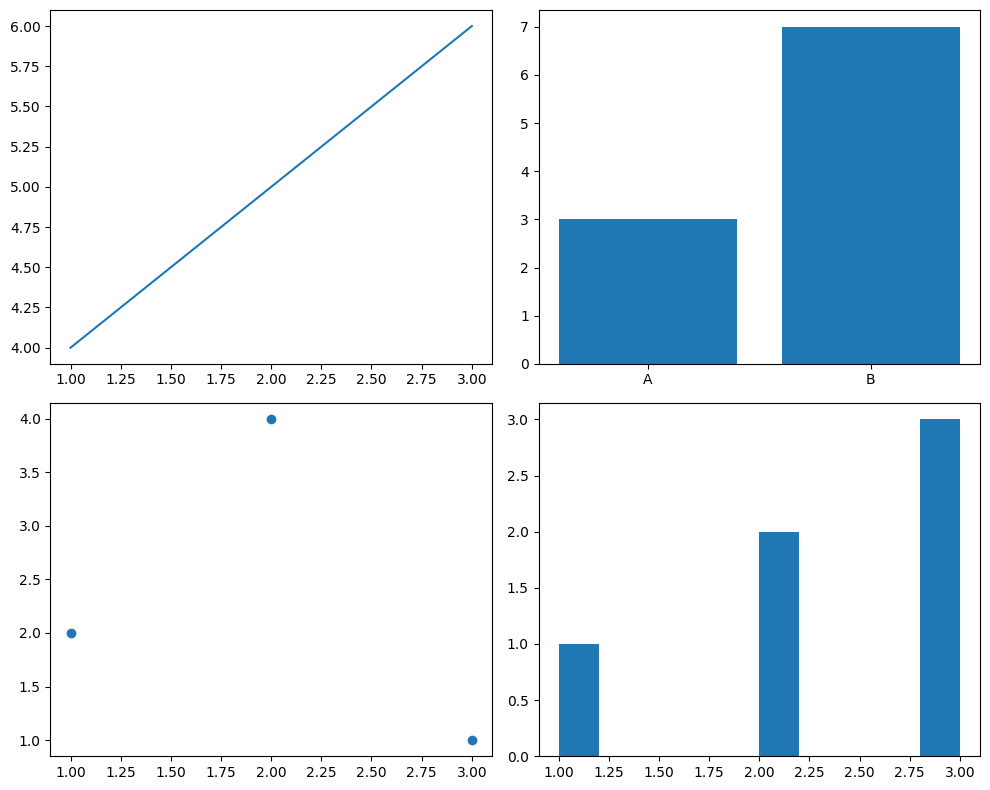

In [2]:
import matplotlib.pyplot as plt

# Cria uma grade 2x2 de subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Acessa cada eixo individualmente
axes[0, 0].plot([1, 2, 3], [4, 5, 6])
axes[0, 1].bar(['A', 'B'], [3, 7])
axes[1, 0].scatter([1, 2, 3], [2, 4, 1])
axes[1, 1].hist([1, 2, 2, 3, 3, 3])

plt.tight_layout()
plt.show()


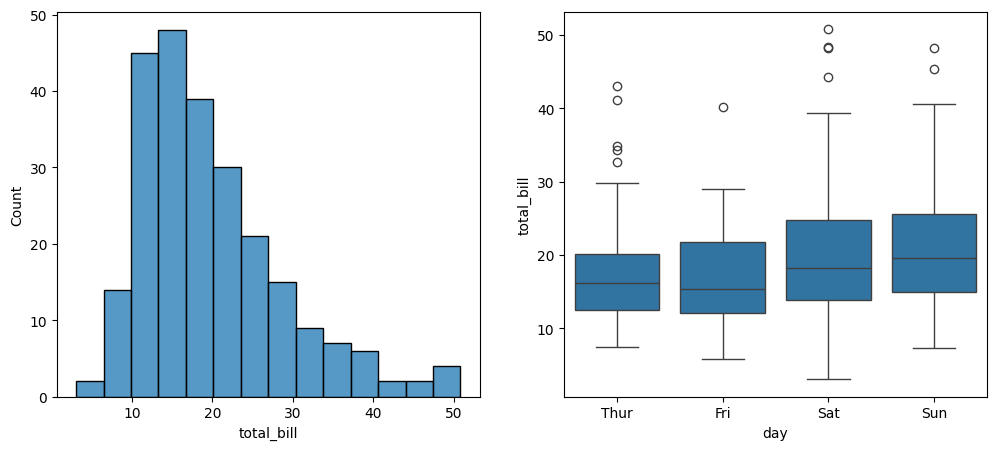

In [3]:
import seaborn as sns

# Carrega dataset de exemplo
tips = sns.load_dataset("tips")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma no primeiro eixo
sns.histplot(data=tips, x="total_bill", ax=axes[0])

# Boxplot no segundo eixo
sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[1])

plt.show()


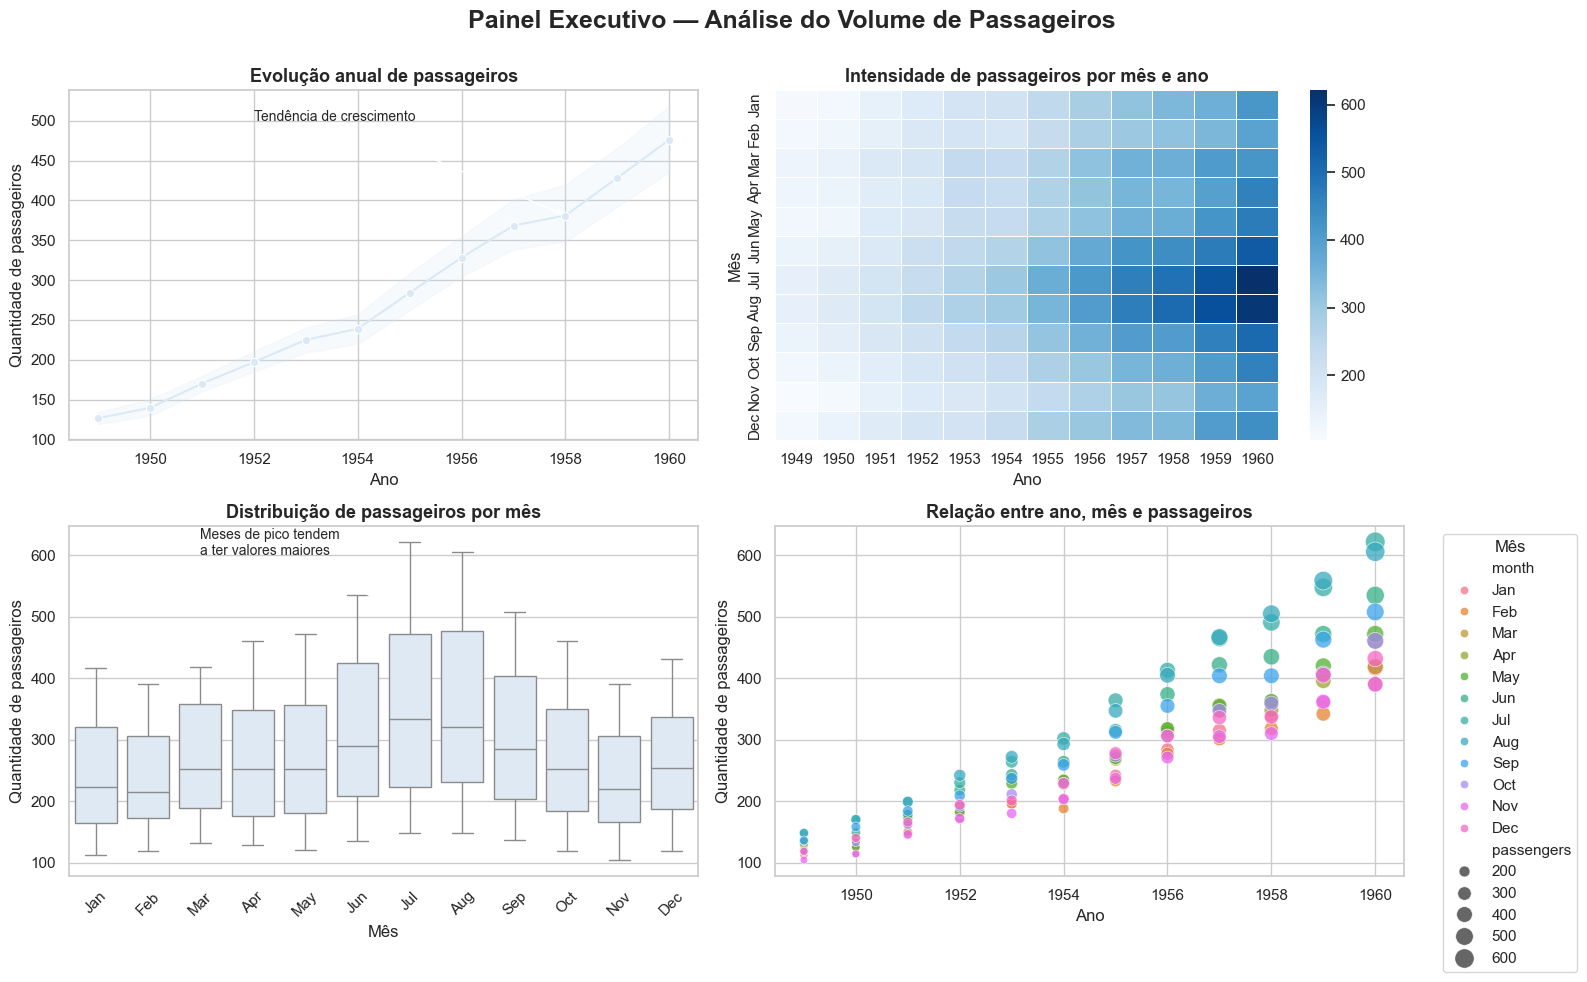

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar dataset
flights = sns.load_dataset("flights")

# Tema, paleta e contexto
sns.set_theme(
    style="whitegrid",
    palette="Blues",
    context="notebook"
)

# Criar painel 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -----------------------------
# 1. Linha temporal
# -----------------------------
sns.lineplot(
    data=flights,
    x="year",
    y="passengers",
    marker="o",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Evolução anual de passageiros", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Ano")
axes[0, 0].set_ylabel("Quantidade de passageiros")

axes[0, 0].annotate(
    "Tendência de crescimento",
    xy=(1958, flights[flights["year"] == 1958]["passengers"].mean()),
    xytext=(1952, 500),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)
# Criar base para o heatmap
flights_pivot = flights.pivot(
    index="month",
    columns="year",
    values="passengers"
)
# -----------------------------
# 2. Heatmap
# -----------------------------
sns.heatmap(
    flights_pivot,
    cmap="Blues",
    annot=False,
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Intensidade de passageiros por mês e ano", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("Ano")
axes[0, 1].set_ylabel("Mês")

# -----------------------------
# 3. Boxplot
# -----------------------------
sns.boxplot(
    data=flights,
    x="month",
    y="passengers",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribuição de passageiros por mês", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Mês")
axes[1, 0].set_ylabel("Quantidade de passageiros")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 0].annotate(
    "Meses de pico tendem\na ter valores maiores",
    xy=(6, 500),
    xytext=(2, 600),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# -----------------------------
# 4. Scatterplot
# -----------------------------
sns.scatterplot(
    data=flights,
    x="year",
    y="passengers",
    hue="month",
    size="passengers",
    sizes=(30, 200),
    alpha=0.75,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Relação entre ano, mês e passageiros", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Ano")
axes[1, 1].set_ylabel("Quantidade de passageiros")

# Ajustar legenda
axes[1, 1].legend(
    title="Mês",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Título geral
fig.suptitle(
    "Painel Executivo — Análise do Volume de Passageiros",
    fontsize=18,
    weight="bold"
)

# Ajustar espaçamento
plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

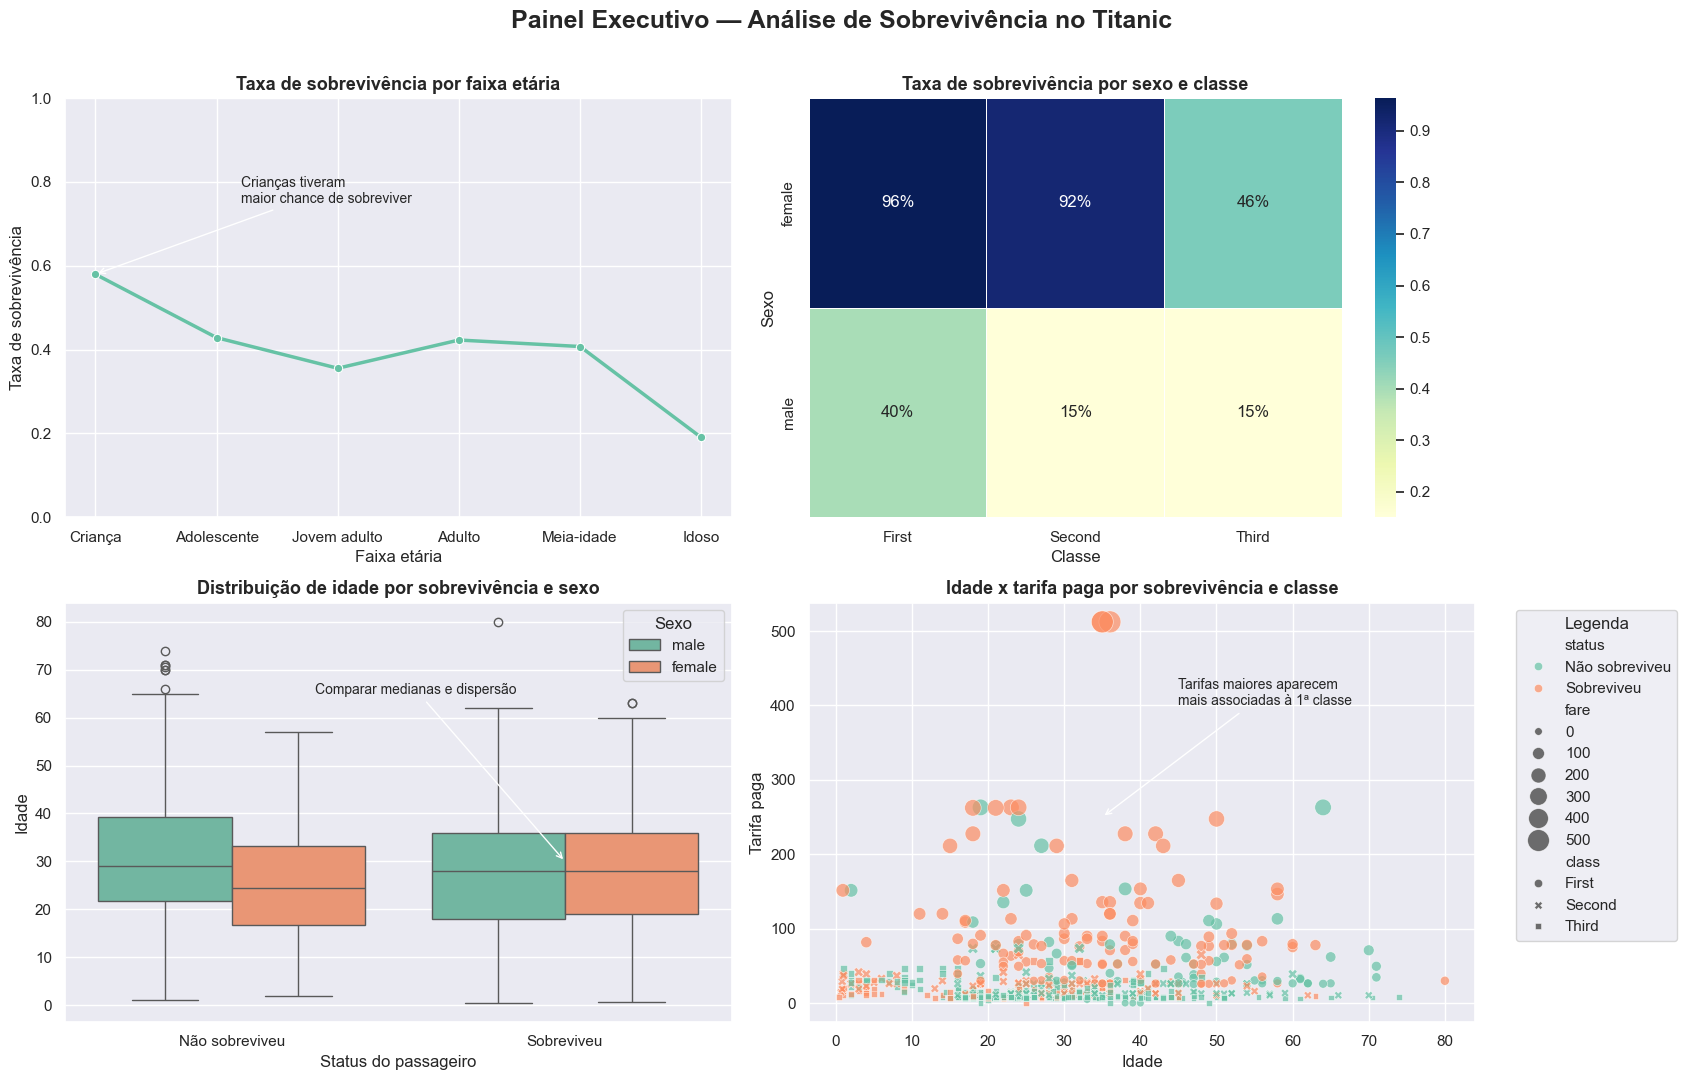

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Carregar o dataset Titanic
titanic = sns.load_dataset("titanic")

# Remover registros sem idade e sem tarifa para evitar problemas nos gráficos
df = titanic.dropna(subset=["age", "fare", "sex", "class", "survived", "embark_town"]).copy()

# Criar uma coluna mais interpretável para sobrevivência
df["status"] = df["survived"].map({
    0: "Não sobreviveu",
    1: "Sobreviveu"
})

# Agrupar idade em faixas para o gráfico de linha
df["faixa_idade"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 30, 45, 60, 80],
    labels=["Criança", "Adolescente", "Jovem adulto", "Adulto", "Meia-idade", "Idoso"]
)

# Tema geral
sns.set_theme(
    style="darkgrid",
    palette="Set2",
    context="notebook"
)

# Criar painel 2x2
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# --------------------------------------------------
# 1. Linha temporal / ordenada: sobrevivência por faixa etária
# --------------------------------------------------
sobrevivencia_idade = (
    df.groupby("faixa_idade", observed=True)["survived"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=sobrevivencia_idade,
    x="faixa_idade",
    y="survived",
    marker="o",
    linewidth=2.5,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Taxa de sobrevivência por faixa etária", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("Faixa etária")
axes[0, 0].set_ylabel("Taxa de sobrevivência")
axes[0, 0].set_ylim(0, 1)

axes[0, 0].annotate(
    "Crianças tiveram\nmaior chance de sobreviver",
    xy=(0, sobrevivencia_idade.loc[0, "survived"]),
    xytext=(1.2, 0.75),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# --------------------------------------------------
# 2. Heatmap: sobrevivência por sexo e classe
# --------------------------------------------------
heatmap_data = df.pivot_table(
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean",
    observed=True
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Taxa de sobrevivência por sexo e classe", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("Classe")
axes[0, 1].set_ylabel("Sexo")

# --------------------------------------------------
# 3. Boxplot: idade por sobrevivência e sexo
# --------------------------------------------------
sns.boxplot(
    data=df,
    x="status",
    y="age",
    hue="sex",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribuição de idade por sobrevivência e sexo", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Status do passageiro")
axes[1, 0].set_ylabel("Idade")
axes[1, 0].legend(title="Sexo")

axes[1, 0].annotate(
    "Comparar medianas e dispersão",
    xy=(1, 30),
    xytext=(0.25, 65),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# --------------------------------------------------
# 4. Scatterplot: idade x tarifa, relacionando classe e sobrevivência
# --------------------------------------------------
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="status",
    style="class",
    size="fare",
    sizes=(30, 250),
    alpha=0.7,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Idade x tarifa paga por sobrevivência e classe", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Idade")
axes[1, 1].set_ylabel("Tarifa paga")

axes[1, 1].annotate(
    "Tarifas maiores aparecem\nmais associadas à 1ª classe",
    xy=(35, 250),
    xytext=(45, 400),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

axes[1, 1].legend(
    title="Legenda",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Título geral
fig.suptitle(
    "Painel Executivo — Análise de Sobrevivência no Titanic",
    fontsize=18,
    weight="bold"
)

# Ajuste de espaçamento
plt.tight_layout()
plt.subplots_adjust(top=0.90)

plt.show()

/var/folders/2s/j4trkh_x5d39tyrtrcmfqshh0000gn/T/ipykernel_1602/3577619856.py:122: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  text=heatmap_data.applymap(lambda x: f"{x:.0%}").values,
